***Objective***

To build s convolutional autoencoder (CAE) that compresses facial images into a lower_dimensional  representation and reconstruct them with minimal loss of information.

 **Purpose**

A convolution Autoencoder is an unsupervised deep learning model used for:
Image compression Image Reconstruction Feature Extraction Dimensionality Reduction  
The encoder learns a compressed representation (latent space), while the decoder reconstructs the original image from this compressed representation.


In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras import Input
from tensorflow.keras import Model

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
path

'/kaggle/input/celeba-dataset'

In [ ]:
  from google .colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"bhavanarraj","key":"75b1c33f9ec0b3122117b57570fab580"}'}

In [ ]:
#Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
#Download Dataset
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:06<00:00, 216MB/s]



In [ ]:
!unzip -q celeba-dataset.zip

In [ ]:
import os
import shutil
source_folder= os.path.join(path,"img_align_celeba","img_align_celeba") # Modified this line
destination_folder= "celeba_small/faces"
os.makedirs(destination_folder,exist_ok=True)
images=sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder,image),
      destination_folder)

print("Copied",len(images),"images")

Copied 5000 images


In [ ]:
#Data Preprocessing
IMAGE_SIZE = (64,64)

BATCH_SIZE = 32


In [ ]:
from IPython.utils.text import re
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
#Load Dataset
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"


)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


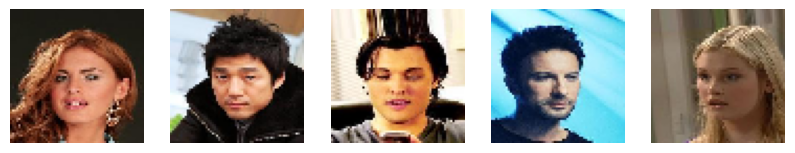

In [ ]:
#Display Sample Images
images,_=next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [ ]:
#Encoder
input_img=Input(shape=(64,64,3))
x=Conv2D(
    32,
     (3,3),
    activation="relu",
    padding="same"
    )(input_img)
x=Conv2D(
    32,
    (2,2),
         padding="same"
         )(x)
x= Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)
encoded=MaxPooling2D(
    (2,2),
    padding="same"
    )(x)

In [ ]:
#Decoder
x=Conv2D(64,(3,3),activation="relu",padding="same")(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
decoded=Conv2D(3,(3,3),activation='sigmoid',padding='same')(x)

In [ ]:
#Create Model
autoencoder=Model(input_img,decoded)

In [ ]:
#Complie Model
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

In [ ]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,779 (311.64 KB)

 Trainable params: 79,779 (311.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train Model
autoencoder.compile(optimizer='adam', loss='mse')
history  = autoencoder.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)



Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - loss: 0.0173 - val_loss: 0.0059
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - loss: 0.0044 - val_loss: 0.0033
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - loss: 0.0031 - val_loss: 0.0026
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - loss: 0.0024 - val_loss: 0.0022
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - loss: 0.0019 - val_loss: 0.0022
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - loss: 0.0017 - val_loss: 0.0016
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - loss: 0.0015 - val_loss: 0.0016
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - loss: 0.0014 - val_loss: 0.0014
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - loss: 0.0013 - val_loss: 0.0013


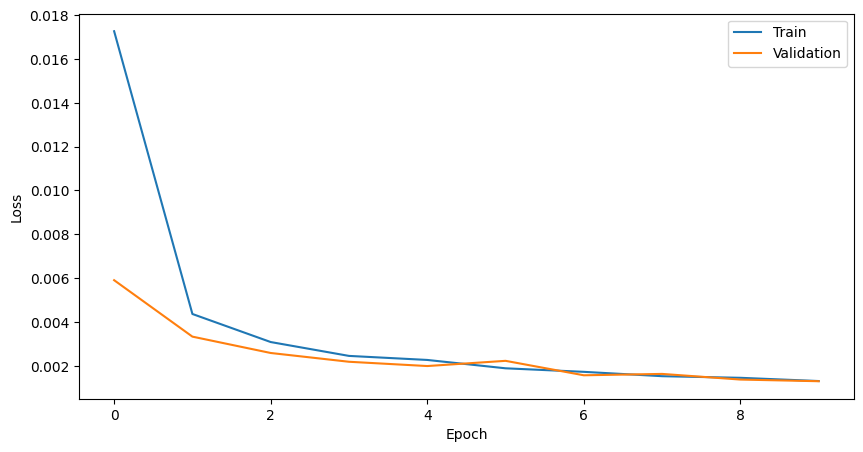

In [ ]:
import matplotlib.pyplot as plt

#plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train vs Validation Loss'])
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
#Reconstuct Images
images,_=next(train_generator)
reconstructed_images=autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step


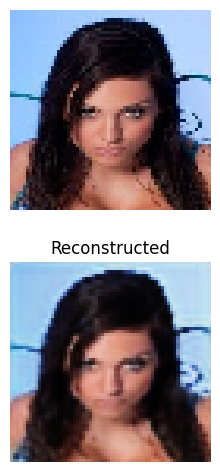

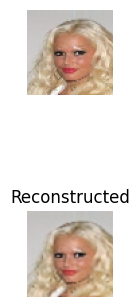

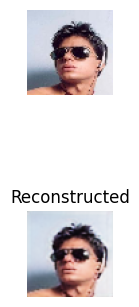

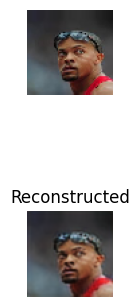

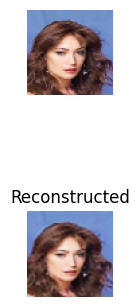

In [ ]:
#Display Results
n = 5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.axis("off")
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed_images[i])
  plt.title("Reconstructed")
  plt.axis("off")
  plt.show()